# FURAP-AI



# Business Understanding

FURAP-AI dikembangkan sebagai sistem rekomendasi wisata yang bertujuan membantu pengguna dalam menemukan destinasi dan menyusun rencana perjalanan secara lebih mudah. Sistem ini berfokus pada pemanfaatan data destinasi wisata, preferensi pengguna, estimasi anggaran, serta durasi perjalanan untuk menghasilkan rekomendasi yang lebih relevan. Pada tahap ini, tujuan utama proyek adalah memahami kebutuhan pengguna dalam proses perencanaan wisata dan menentukan bagaimana teknologi machine learning dapat digunakan untuk mendukung pengambilan keputusan secara lebih personal dan efisien.

# Data Understanding



## Install library

In [1]:
!pip install pandas numpy scikit-learn plotly joblib

## Import library

In [2]:
import re
import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import files
uploaded = files.upload()

Saving bandung_dataset_ml.csv to bandung_dataset_ml.csv


In [4]:
df_raw = pd.read_csv("bandung_dataset_ml.csv")
print("Ukuran data:", df_raw.shape)
df_raw.head()

Ukuran data: (1000, 32)


,id_data,lokasi_awal_user,durasi_perjalanan,jumlah_hari,jumlah_orang,budget,segmen_budget,jenis_transportasi,preferensi_penginapan,preferensi_kategori,...,kecocokan_jarak,estimasi_jarak_km,estimasi_waktu_menit,estimasi_biaya_transportasi,estimasi_biaya_penginapan,estimasi_biaya_makan,estimasi_biaya_tiket,total_estimasi_biaya,status_budget,label_rekomendasi
0,BDG-TRV-0001,Kabupaten Bandung,1 hari,1,5,970000,standar,mobil,tanpa penginapan,kebun binatang,...,1,54.58,93,327000,0,350000,75000,752000,sesuai,0
1,BDG-TRV-0002,Jakarta,1 hari,1,2,1761000,standar,mobil,tanpa penginapan,alam,...,0,192.52,316,1155000,0,140000,60000,1355000,sesuai,0
2,BDG-TRV-0003,Depok,3 hari 2 malam,3,4,3230000,hemat,mobil,standar,wisata kuliner,...,1,206.88,460,1241000,640000,840000,60000,2781000,sesuai,1
3,BDG-TRV-0004,Kota Bandung,2 hari 1 malam,2,5,1858000,hemat,motor,standar,wisata alam,...,1,41.66,82,117000,320000,700000,150000,1287000,sesuai,1
4,BDG-TRV-0005,Bogor,2 hari 1 malam,2,2,1014000,standar,mobil,hemat,cafe view,...,1,191.66,439,1150000,180000,280000,40000,1650000,melebihi budget,0


In [5]:
assert df_raw.shape[0] == 1000, "Jumlah data tidak sesuai. Pastikan file bandung_dataset_ml.csv versi 1000 data yang digunakan."

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_data                      1000 non-null   object 
 1   lokasi_awal_user             1000 non-null   object 
 2   durasi_perjalanan            1000 non-null   object 
 3   jumlah_hari                  1000 non-null   int64  
 4   jumlah_orang                 1000 non-null   int64  
 5   budget                       1000 non-null   int64  
 6   segmen_budget                1000 non-null   object 
 7   jenis_transportasi           1000 non-null   object 
 8   preferensi_penginapan        1000 non-null   object 
 9   preferensi_kategori          1000 non-null   object 
 10  preferensi_aktivitas         1000 non-null   object 
 11  nama_wisata                  1000 non-null   object 
 12  kategori_wisata              1000 non-null   object 
 13  kota_tujuan        

In [7]:
category_dist = (
    df_raw["kategori_wisata"]
    .value_counts()
    .reset_index()
)
category_dist.columns = ["kategori_wisata", "jumlah"]

fig = px.bar(
    category_dist,
    x="kategori_wisata",
    y="jumlah",
    title="Distribusi Kategori Destinasi",
    labels={"kategori_wisata": "Kategori", "jumlah": "Jumlah Data"}
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [8]:
label_dist = (
    df_raw["label_rekomendasi"]
    .value_counts()
    .sort_index()
    .reset_index()
)
label_dist.columns = ["label_rekomendasi", "jumlah"]
label_dist

,label_rekomendasi,jumlah
0,0,500
1,1,500


In [9]:
fig = px.bar(
    label_dist,
    x="label_rekomendasi",
    y="jumlah",
    text="jumlah",
    title="Distribusi Label Rekomendasi",
    labels={"label_rekomendasi": "Label", "jumlah": "Jumlah Data"}
)
fig.show()

# Data Preparation



## EDA (Exploratory Data Analysis)

### Remove duplicate records

Data duplikat dihapus agar model tidak belajar dari baris yang sama secara berulang.

In [10]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Data sebelum:", before)
print("Data sesudah:", after)
print("Duplikat dihapus:", before - after)

Data sebelum: 1000
Data sesudah: 1000
Duplikat dihapus: 0


### Handle missing data

Nilai kosong pada kolom teks diisi dengan string kosong, sedangkan kolom numerik diisi menggunakan median.

In [11]:
missing_before = df.isna().sum().sort_values(ascending=False)
missing_before[missing_before > 0]

,0


In [12]:
text_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=np.number).columns

for col in text_cols:
    df[col] = df[col].fillna("")

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

print("Total missing value:", int(df.isna().sum().sum()))

Total missing value: 0


### Unify inconsistent data formats

Format teks dibuat konsisten agar kategori yang sama tidak terbaca sebagai nilai berbeda hanya karena huruf besar, spasi, atau simbol.

In [13]:
def clean_text(value):
    value = str(value).lower().strip()
    value = re.sub(r"\s+", " ", value)
    return value

for col in text_cols:
    df[col] = df[col].apply(clean_text)

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

sample_cols = ["lokasi_awal_user", "preferensi_kategori", "preferensi_aktivitas", "nama_wisata", "kategori_wisata"]
df[sample_cols].head()

,lokasi_awal_user,preferensi_kategori,preferensi_aktivitas,nama_wisata,kategori_wisata
0,kabupaten bandung,kebun binatang,foto-foto,floating market lembang,wisata kuliner
1,jakarta,alam,kuliner,curug cimahi,wisata alam
2,depok,wisata kuliner,foto-foto,floating market lembang,wisata kuliner
3,kota bandung,wisata alam,alam,kawah putih,wisata alam
4,bogor,cafe view,kuliner,cafe d'pakar bandung,cafe view


### Split and combine columns


In [14]:
if "koordinat_destinasi" in df.columns:
    koordinat_split = df["koordinat_destinasi"].astype(str).str.split(",", expand=True)
    if koordinat_split.shape[1] >= 2:
        df["latitude_clean"] = pd.to_numeric(koordinat_split[0], errors="coerce")
        df["longitude_clean"] = pd.to_numeric(koordinat_split[1], errors="coerce")
        df["latitude"] = df["latitude"].fillna(df["latitude_clean"])
        df["longitude"] = df["longitude"].fillna(df["longitude_clean"])
        df = df.drop(columns=["latitude_clean", "longitude_clean"])
text_for_model = [
    "preferensi_kategori",
    "preferensi_aktivitas",
    "segmen_budget",
    "jenis_transportasi",
    "preferensi_penginapan",
    "kategori_wisata",
    "deskripsi_wisata"
]
df["teks_model"] = df[text_for_model].agg(" ".join, axis=1)
df[["teks_model"]].head()

,teks_model
0,kebun binatang foto-foto standar mobil tanpa p...
1,alam kuliner standar mobil tanpa penginapan wi...
2,wisata kuliner foto-foto hemat mobil standar w...
3,wisata alam alam hemat motor standar wisata al...
4,cafe view kuliner standar mobil hemat cafe vie...


### Group data

Ringkasan dibuat untuk melihat kategori dan label rekomendasi. Tahap ini tidak mengubah data training.

In [15]:
group_summary = (
    df.groupby(["kategori_wisata", "label_rekomendasi"])
    .size()
    .reset_index(name="jumlah")
    .sort_values(["kategori_wisata", "label_rekomendasi"])
)

group_summary.head(10)

,kategori_wisata,label_rekomendasi,jumlah
0,cafe view,0,25
1,cafe view,1,32
2,gunung,0,29
3,gunung,1,32
4,kebun binatang,0,16
5,kebun binatang,1,24
6,mall,0,88
7,mall,1,71
8,museum,0,50
9,museum,1,40


### Ringkasan fitur numerik

In [16]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols].describe()

,jumlah_hari,jumlah_orang,budget,latitude,longitude,kecocokan_kategori,kecocokan_aktivitas,kecocokan_budget,kecocokan_jarak,estimasi_jarak_km,estimasi_waktu_menit,estimasi_biaya_transportasi,estimasi_biaya_penginapan,estimasi_biaya_makan,estimasi_biaya_tiket,total_estimasi_biaya,label_rekomendasi
count,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03,1000.00000
mean,2.272000,2.81800,2.241739e+06,-6.884760,107.602200,0.810000,0.780000,0.720000,0.840000,142.356870,271.69200,5.867290e+05,4.243400e+05,4.480000e+05,61485.000000,1.520554e+06,0.50000
std,0.953376,1.36115,1.261035e+06,0.086161,0.058675,0.392497,0.414454,0.449224,0.366789,85.421004,168.31086,4.201065e+05,3.832895e+05,3.011995e+05,52507.874189,7.388004e+05,0.50025
min,1.000000,1.00000,1.000000e+05,-7.166200,107.358900,0.000000,0.000000,0.000000,0.000000,5.250000,11.00000,1.600000e+04,0.000000e+00,7.000000e+04,0.000000,1.130000e+05,0.00000
25%,2.000000,2.00000,1.267750e+06,-6.917500,107.596900,1.000000,1.000000,0.000000,1.000000,63.930000,113.75000,2.417500e+05,1.800000e+05,2.100000e+05,30000.000000,9.855000e+05,0.00000
50%,2.000000,2.00000,2.071500e+06,-6.899200,107.609700,1.000000,1.000000,1.000000,1.000000,156.310000,287.00000,5.480000e+05,3.600000e+05,4.200000e+05,50000.000000,1.433000e+06,0.50000
75%,3.000000,4.00000,3.004500e+06,-6.829100,107.621500,1.000000,1.000000,1.000000,1.000000,199.822500,388.00000,8.010000e+05,6.400000e+05,6.300000e+05,75000.000000,1.967500e+06,1.00000
max,4.000000,5.00000,4.982000e+06,-6.759600,107.687500,1.000000,1.000000,1.000000,1.000000,430.570000,863.00000,2.583000e+06,1.560000e+06,1.400000e+06,325000.000000,4.425000e+06,1.00000


### Filter irrelevant data

Kolom identitas, label, status hasil, serta informasi yang hanya untuk tampilan tidak dimasukkan sebagai fitur training. Kolom kecocokan tetap dipakai karena nilainya bisa dihitung ulang saat user mengisi form di aplikasi.

In [17]:
target_col = "label_rekomendasi"

forbidden_features = [
    "id_data",
    "nama_wisata",
    "alamat",
    "status_budget",
    "label_rekomendasi"
]

feature_cols = [
    "teks_model",
    "jumlah_hari",
    "jumlah_orang",
    "budget",
    "kecocokan_kategori",
    "kecocokan_aktivitas",
    "kecocokan_budget",
    "kecocokan_jarak",
    "estimasi_jarak_km",
    "estimasi_waktu_menit",
    "total_estimasi_biaya"
]

leak_check = set(feature_cols).intersection(set(forbidden_features))
assert len(leak_check) == 0, f"Fitur leakage masih masuk training: {leak_check}"

X = df[feature_cols].copy()
y = df[target_col].astype(int)

X.head()

,teks_model,jumlah_hari,jumlah_orang,budget,kecocokan_kategori,kecocokan_aktivitas,kecocokan_budget,kecocokan_jarak,estimasi_jarak_km,estimasi_waktu_menit,total_estimasi_biaya
0,kebun binatang foto-foto standar mobil tanpa p...,1,5,970000,0,1,1,1,54.58,93,752000
1,alam kuliner standar mobil tanpa penginapan wi...,1,2,1761000,1,0,1,0,192.52,316,1355000
2,wisata kuliner foto-foto hemat mobil standar w...,3,4,3230000,1,1,1,1,206.88,460,2781000
3,wisata alam alam hemat motor standar wisata al...,2,5,1858000,1,1,1,1,41.66,82,1287000
4,cafe view kuliner standar mobil hemat cafe vie...,2,2,1014000,1,1,0,1,191.66,439,1650000


##  Modeling



## Split train and tes

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print(y_train.value_counts().sort_index())

Train: (800, 11)
Test : (200, 11)
label_rekomendasi
0    400
1    400
Name: count, dtype: int64


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=900,
                min_df=2,
                ngram_range=(1, 2),
                sublinear_tf=True
            ),
            "teks_model"
        ),
        (
            "numeric",
            StandardScaler(with_mean=False),
            [col for col in feature_cols if col != "teks_model"]
        )
    ]
)

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(
            n_neighbors=21,
            weights="uniform",
            metric="cosine"
        ))
    ]
)

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.985
Precision: 0.9709
Recall   : 1.0
F1-Score : 0.9852


# Evaluation

In [20]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Tidak Direkomendasikan", "Direkomendasikan"]
))

                        precision    recall  f1-score   support

Tidak Direkomendasikan       1.00      0.97      0.98       100
      Direkomendasikan       0.97      1.00      0.99       100

              accuracy                           0.98       200
             macro avg       0.99      0.98      0.98       200
          weighted avg       0.99      0.98      0.98       200



In [21]:
cm = confusion_matrix(y_test, y_pred)

fig = px.imshow(
    cm,
    text_auto=True,
    labels=dict(x="Prediksi", y="Aktual", color="Jumlah"),
    x=["Tidak Direkomendasikan", "Direkomendasikan"],
    y=["Tidak Direkomendasikan", "Direkomendasikan"],
    title="Confusion Matrix model KNN"
)
fig.show()

### Cross-validation

Cross-validation digunakan untuk melihat apakah performa model stabil pada beberapa pembagian data, bukan hanya pada satu train-test split.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    knn_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=True
)

cv_result = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score"],
    "train_mean": [
        cv_scores["train_accuracy"].mean(),
        cv_scores["train_precision"].mean(),
        cv_scores["train_recall"].mean(),
        cv_scores["train_f1"].mean()
    ],
    "validation_mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean()
    ]
})

cv_result

,metric,train_mean,validation_mean
0,accuracy,0.989000,0.986000
1,precision,0.978554,0.973701
2,recall,1.000000,1.000000
3,f1_score,0.989140,0.986442


### Learning curve

Learning curve dipakai untuk mengecek jarak antara performa training dan validasi.

In [23]:
train_sizes, train_scores, val_scores = learning_curve(
    knn_model,
    X,
    y,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=None
)

curve_df = pd.DataFrame({
    "jumlah_data_training": train_sizes,
    "training_f1": train_scores.mean(axis=1),
    "validation_f1": val_scores.mean(axis=1)
})

curve_df

,jumlah_data_training,training_f1,validation_f1
0,160,0.872780,0.895454
1,320,0.915272,0.913181
2,480,0.953914,0.939366
3,640,0.980276,0.974114
4,800,0.989140,0.986442


In [24]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=curve_df["jumlah_data_training"],
    y=curve_df["training_f1"],
    mode="lines+markers",
    name="Training"
))
fig.add_trace(go.Scatter(
    x=curve_df["jumlah_data_training"],
    y=curve_df["validation_f1"],
    mode="lines+markers",
    name="Validation"
))
fig.update_layout(
    title="Learning Curve - KNN",
    xaxis_title="Jumlah Data Training",
    yaxis_title="F1-Score"
)
fig.show()

### Content-based similarity


In [25]:
destination_base = (
    df[["nama_wisata", "kategori_wisata", "kota_tujuan", "alamat", "deskripsi_wisata", "latitude", "longitude"]]
    .drop_duplicates(subset=["nama_wisata"])
    .reset_index(drop=True)
)

destination_base["teks_destinasi"] = (
    destination_base["nama_wisata"] + " " +
    destination_base["kategori_wisata"] + " " +
    destination_base["kota_tujuan"] + " " +
    destination_base["deskripsi_wisata"]
)

destination_tfidf = TfidfVectorizer(
    max_features=700,
    min_df=1,
    ngram_range=(1, 2),
    sublinear_tf=True
)

destination_matrix = destination_tfidf.fit_transform(destination_base["teks_destinasi"])

content_knn = NearestNeighbors(
    n_neighbors=6,
    metric="cosine"
)
content_knn.fit(destination_matrix)

print("Jumlah destinasi unik:", destination_base.shape[0])

Jumlah destinasi unik: 31


In [26]:
def recommend_destinations(query, top_n=5):
    query_vector = destination_tfidf.transform([clean_text(query)])
    distances, indices = content_knn.kneighbors(query_vector, n_neighbors=top_n)

    result = destination_base.iloc[indices[0]].copy()
    result["similarity_score"] = 1 - distances[0]
    return result[["nama_wisata", "kategori_wisata", "kota_tujuan", "deskripsi_wisata", "similarity_score"]]

recommend_destinations("wisata edukasi museum sejarah keluarga", top_n=5)

,nama_wisata,kategori_wisata,kota_tujuan,deskripsi_wisata,similarity_score
9,museum konferensi asia afrika,museum,kota bandung,museum konferensi asia afrika menyajikan sejar...,0.326023
10,museum geologi bandung,museum,kota bandung,museum geologi bandung adalah destinasi edukas...,0.283570
7,jendela alam,wisata edukasi,kabupaten bandung barat,jendela alam adalah wisata edukasi keluarga ya...,0.206645
28,gedung sate,wisata edukasi,kota bandung,gedung sate adalah ikon kota bandung yang dike...,0.176407
29,taman lalu lintas bandung,wisata edukasi,kota bandung,taman lalu lintas bandung adalah tempat wisata...,0.157656


# Deployment

### Simpan artifact

In [27]:
joblib.dump(knn_model, "furap_AI_model.pkl")
joblib.dump(destination_tfidf, "furap_destination_tfidf.pkl")
joblib.dump(content_knn, "furap_content_knn.pkl")
joblib.dump(destination_base, "furap_destination_base.pkl")
print("Artifact berhasil disimpan.")

Artifact berhasil disimpan.


# Deep Learning - Tempat Wisata



## Persiapan library

In [28]:
!pip install tensorflow pillow plotly matplotlib -q

In [29]:
import os
import re
import zipfile
import shutil
import random
import hashlib
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from PIL import Image, ImageOps
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
DL_ZIP_PATH = Path("bandung_dataset_dl.zip")
print("TensorFlow:", tf.__version__)
print("Dataset DL ditemukan:", DL_ZIP_PATH.exists())

TensorFlow: 2.20.0
Dataset DL ditemukan: True


## Load dataset gambar terbaru

In [30]:
DL_RAW_DIR = Path("dl_raw")
DL_SOURCE_DIR = Path("furap_image_dataset")
if DL_RAW_DIR.exists():
    shutil.rmtree(DL_RAW_DIR)
if DL_SOURCE_DIR.exists():
    shutil.rmtree(DL_SOURCE_DIR)
DL_RAW_DIR.mkdir(parents=True, exist_ok=True)
DL_SOURCE_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(DL_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DL_RAW_DIR)
valid_ext = {".jpg", ".jpeg", ".png", ".webp"}
candidate_dirs = [p for p in DL_RAW_DIR.rglob("*") if p.is_dir()]
image_roots = []
for p in candidate_dirs:
    image_count = len([
        img for img in p.rglob("*")
        if img.is_file() and img.suffix.lower() in valid_ext
    ])
    if image_count > 0:
        image_roots.append((p, image_count))
if not image_roots:
    raise ValueError("Struktur folder gambar tidak ditemukan di bandung_dataset_dl.zip")
source_root = sorted(image_roots, key=lambda x: x[1], reverse=True)[0][0]
print("Root dataset gambar:", source_root)
print("Jumlah gambar terdeteksi:", sorted(image_roots, key=lambda x: x[1], reverse=True)[0][1])

Root dataset gambar: dl_raw/bandung_dataset_dl
Jumlah gambar terdeteksi: 160


## Validasi gambar dan normalisasi nama class

In [31]:
def slugify(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text
rows = []
bad_files = []
duplicates = []
hashes = {}

for class_dir in source_root.iterdir():
    if not class_dir.is_dir():
        continue

    class_name = slugify(class_dir.name)
    target_dir = DL_SOURCE_DIR / class_name
    target_dir.mkdir(parents=True, exist_ok=True)

    image_files = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in valid_ext
    ]

    for idx, img_path in enumerate(sorted(image_files), start=1):
        try:
            with Image.open(img_path) as img:
                img = ImageOps.exif_transpose(img).convert("RGB")
                width, height = img.size

            file_hash = hashlib.md5(img_path.read_bytes()).hexdigest()
            rel_path = str(img_path.relative_to(source_root))

            if file_hash in hashes:
                duplicates.append({
                    "file": rel_path,
                    "same_as": hashes[file_hash]
                })
            else:
                hashes[file_hash] = rel_path

            new_name = f"{class_name}_{idx:03d}.jpg"
            target_path = target_dir / new_name

            with Image.open(img_path) as img:
                img = ImageOps.exif_transpose(img).convert("RGB")
                img.save(target_path, quality=92)

            rows.append({
                "nama_wisata": class_dir.name,
                "class_name": class_name,
                "image_path": str(target_path),
                "width": width,
                "height": height,
                "min_side": min(width, height)
            })

        except Exception as error:
            bad_files.append({
                "file": str(img_path),
                "error": str(error)
            })

dl_manifest_source = pd.DataFrame(rows)
bad_files_df = pd.DataFrame(bad_files)
duplicates_df = pd.DataFrame(duplicates)

print("Total gambar valid:", len(dl_manifest_source))
print("File corrupt/rusak:", len(bad_files_df))
print("Exact duplicate:", len(duplicates_df))

if len(bad_files_df) > 0:
    display(bad_files_df)

if len(duplicates_df) > 0:
    display(duplicates_df)

Total gambar valid: 160
File corrupt/rusak: 0
Exact duplicate: 0


## Audit jumlah gambar per class

In [32]:
dl_counts = (
    dl_manifest_source
    .groupby(["nama_wisata", "class_name"])
    .agg(
        jumlah_gambar=("image_path", "count"),
        min_side_terkecil=("min_side", "min")
    )
    .reset_index()
    .sort_values("class_name")
)
display(dl_counts)
fig = px.bar(
    dl_counts,
    x="class_name",
    y="jumlah_gambar",
    text="jumlah_gambar",
    title="Jumlah Gambar per Class"
)
fig.update_layout(xaxis_tickangle=-35)
fig.show()
min_count = int(dl_counts["jumlah_gambar"].min())
max_count = int(dl_counts["jumlah_gambar"].max())
small_images = int((dl_manifest_source["min_side"] < 224).sum())
print("Jumlah class:", dl_counts.shape[0])
print("Minimal gambar per class:", min_count)
print("Maksimal gambar per class:", max_count)
print("Gambar dengan sisi < 224 px:", small_images)

if min_count < 3:
    raise ValueError("Ada class dengan gambar kurang dari 3. Tambahkan gambar agar bisa split train/valid/test.")

,nama_wisata,class_name,jumlah_gambar,min_side_terkecil
0,Alun-Alun Bandung,alun_alun_bandung,20,168
1,Bandung Indah Plaza,bandung_indah_plaza,20,134
2,Gunung Patuha,gunung_patuha,20,46
3,Jalan Braga Bandung,jalan_braga_bandung,20,162
4,Kawah Kamojang,kawah_kamojang,20,46
5,Kebun Binatang Bandung,kebun_binatang_bandung,20,46
6,Museum Geologi Bandung,museum_geologi_bandung,20,168
7,Trans Studio Bandung,trans_studio_bandung,20,168


Jumlah class: 8
Minimal gambar per class: 20
Maksimal gambar per class: 20
Gambar dengan sisi < 224 px: 71


## Split train / validation / test

In [33]:
def split_per_class(df, random_state=42):
    parts = []
    for class_name, group in df.groupby("class_name"):
        group = group.sample(frac=1, random_state=random_state).reset_index(drop=True)
        n = len(group)
        n_train = max(1, int(np.floor(n * 0.70)))
        n_valid = max(1, int(np.round(n * 0.20)))
        n_test = n - n_train - n_valid
        if n_test < 1:
            n_test = 1
            n_train = n - n_valid - n_test
        train_part = group.iloc[:n_train].copy()
        valid_part = group.iloc[n_train:n_train + n_valid].copy()
        test_part = group.iloc[n_train + n_valid:].copy()
        train_part["split"] = "train"
        valid_part["split"] = "valid"
        test_part["split"] = "test"
        parts.extend([train_part, valid_part, test_part])
    return pd.concat(parts, ignore_index=True)
dl_split = split_per_class(dl_manifest_source, random_state=RANDOM_STATE)
display(dl_split.groupby(["class_name", "split"]).size().reset_index(name="jumlah"))

,class_name,split,jumlah
0,alun_alun_bandung,test,2
1,alun_alun_bandung,train,14
2,alun_alun_bandung,valid,4
3,bandung_indah_plaza,test,2
4,bandung_indah_plaza,train,14
5,bandung_indah_plaza,valid,4
6,gunung_patuha,test,2
7,gunung_patuha,train,14
8,gunung_patuha,valid,4
9,jalan_braga_bandung,test,2


## Bentuk folder dataset CNN

In [34]:
DL_DATASET_DIR = Path("furap_dl_dataset")
if DL_DATASET_DIR.exists():
    shutil.rmtree(DL_DATASET_DIR)
for split in ["train", "valid", "test"]:
    (DL_DATASET_DIR / split).mkdir(parents=True, exist_ok=True)
for _, row in dl_split.iterrows():
    src = Path(row["image_path"])
    dst_dir = DL_DATASET_DIR / row["split"] / row["class_name"]
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name
    shutil.copy(src, dst)
dl_split.to_csv("furap_dl_split_manifest.csv", index=False, encoding="utf-8-sig")
print("Folder dataset CNN selesai dibuat:", DL_DATASET_DIR)

Folder dataset CNN selesai dibuat: furap_dl_dataset


## Load dataset ke TensorFlow

In [35]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
train_ds = image_dataset_from_directory(
    DL_DATASET_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=RANDOM_STATE
)
valid_ds = image_dataset_from_directory(
    DL_DATASET_DIR / "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)
test_ds = image_dataset_from_directory(
    DL_DATASET_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)
class_names = train_ds.class_names
print("Jumlah class:", len(class_names))
print(class_names)

Found 112 files belonging to 8 classes.
Found 32 files belonging to 8 classes.
Found 16 files belonging to 8 classes.
Jumlah class: 8
['alun_alun_bandung', 'bandung_indah_plaza', 'gunung_patuha', 'jalan_braga_bandung', 'kawah_kamojang', 'kebun_binatang_bandung', 'museum_geologi_bandung', 'trans_studio_bandung']


## Hitung class weight

In [36]:
train_counts = dl_split[dl_split["split"] == "train"]["class_name"].value_counts().sort_index()
class_index = {name: idx for idx, name in enumerate(class_names)}
y_train_class = []
for class_name, count in train_counts.items():
    y_train_class.extend([class_index[class_name]] * count)
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=np.array(y_train_class)
)
class_weight = {idx: float(weight) for idx, weight in enumerate(weights)}
class_weight

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}

## Modeling CNN menggunakan Transfer Learning MobileNetV2



In [37]:
tf.keras.backend.clear_session()
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.05),
], name="train_augmentation")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
cnn_model = tf.keras.Model(inputs, outputs)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ train_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,104 (9.26 MB)

 Trainable params: 167,560 (654.53 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Training tahap 1 - Feature Extraction

In [53]:
from pathlib import Path
Path("models").mkdir(exist_ok=True)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="models/furap_cnn_model.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]
history = cnn_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9847 - loss: 0.1363
Epoch 1: val_accuracy improved from None to 0.87500, saving model to models/furap_cnn_model.keras

Epoch 1: finished saving model to models/furap_cnn_model.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9732 - loss: 0.1543 - val_accuracy: 0.8750 - val_loss: 0.6042 - learning_rate: 3.0000e-04
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.9942 - loss: 0.1120
Epoch 2: val_accuracy did not improve from 0.87500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 892ms/step - accuracy: 0.9821 - loss: 0.1117 - val_accuracy: 0.8750 - val_loss: 0.5864 - learning_rate: 3.0000e-04
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 1.0000 - loss: 0.1213
Epoch 3: val_accuracy did not improve from 0.87500
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 1.0000 - loss: 0.1175 - val_accuracy: 0.8750 - val_loss: 0.5689 - learning_rate: 3.0000e-04
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.99

## Evaluation CNN

In [54]:
history_df = pd.DataFrame(history.history)
best_epoch = history_df["val_accuracy"].idxmax()
best_train_acc = history_df.loc[best_epoch, "accuracy"]
best_val_acc = history_df.loc[best_epoch, "val_accuracy"]
best_gap = best_train_acc - best_val_acc
print("Best epoch                 :", best_epoch + 1)
print("Training accuracy terbaik  :", round(best_train_acc, 4))
print("Validation accuracy terbaik:", round(best_val_acc, 4))
print("Gap train-validation       :", round(best_gap, 4))
if best_val_acc >= 0.90:
    print("Validasi sangat baik untuk prototype")
elif best_val_acc >= 0.80:
    print("Validasi sudah baik untuk prototype")
else:
    print("Validasi masih perlu ditingkatkan. Cek variasi gambar, resolusi, atau tambah data")

Best epoch                 : 1
Training accuracy terbaik  : 0.9732
Validation accuracy terbaik: 0.875
Gap train-validation       : 0.0982
Validasi sudah baik untuk prototype


In [55]:
y_true_cnn = []
y_pred_cnn = []
for images, labels in test_ds:
    preds = cnn_model.predict(images, verbose=0)
    y_true_cnn.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_cnn.extend(np.argmax(preds, axis=1))
cm = confusion_matrix(y_true_cnn, y_pred_cnn)
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)
display(cm_df)

,alun_alun_bandung,bandung_indah_plaza,gunung_patuha,jalan_braga_bandung,kawah_kamojang,kebun_binatang_bandung,museum_geologi_bandung,trans_studio_bandung
alun_alun_bandung,2,0,0,0,0,0,0,0
bandung_indah_plaza,0,1,0,1,0,0,0,0
gunung_patuha,0,0,2,0,0,0,0,0
jalan_braga_bandung,0,0,0,2,0,0,0,0
kawah_kamojang,0,0,0,0,2,0,0,0
kebun_binatang_bandung,0,0,0,0,0,2,0,0
museum_geologi_bandung,0,0,0,0,0,0,2,0
trans_studio_bandung,0,0,0,0,0,0,0,2


In [56]:
val_wrong_predictions = []
val_total = 0
for images, labels in valid_ds:
    preds = cnn_model.predict(images, verbose=0)
    for i in range(len(images)):
        val_total += 1
        actual_idx = int(np.argmax(labels[i].numpy()))
        pred_idx = int(np.argmax(preds[i]))
        confidence = float(np.max(preds[i]))
        if actual_idx != pred_idx:
            val_wrong_predictions.append({
                "actual": class_names[actual_idx],
                "predicted": class_names[pred_idx],
                "confidence": confidence,
                "image": images[i].numpy()
            })
val_wrong = len(val_wrong_predictions)
val_correct = val_total - val_wrong
val_acc_manual = val_correct / val_total

print("Total validation :", val_total)
print("Benar validation :", val_correct)
print("Salah validation :", val_wrong)
print("Validation acc   :", round(val_acc_manual, 4))

Total validation : 32
Benar validation : 28
Salah validation : 4
Validation acc   : 0.875


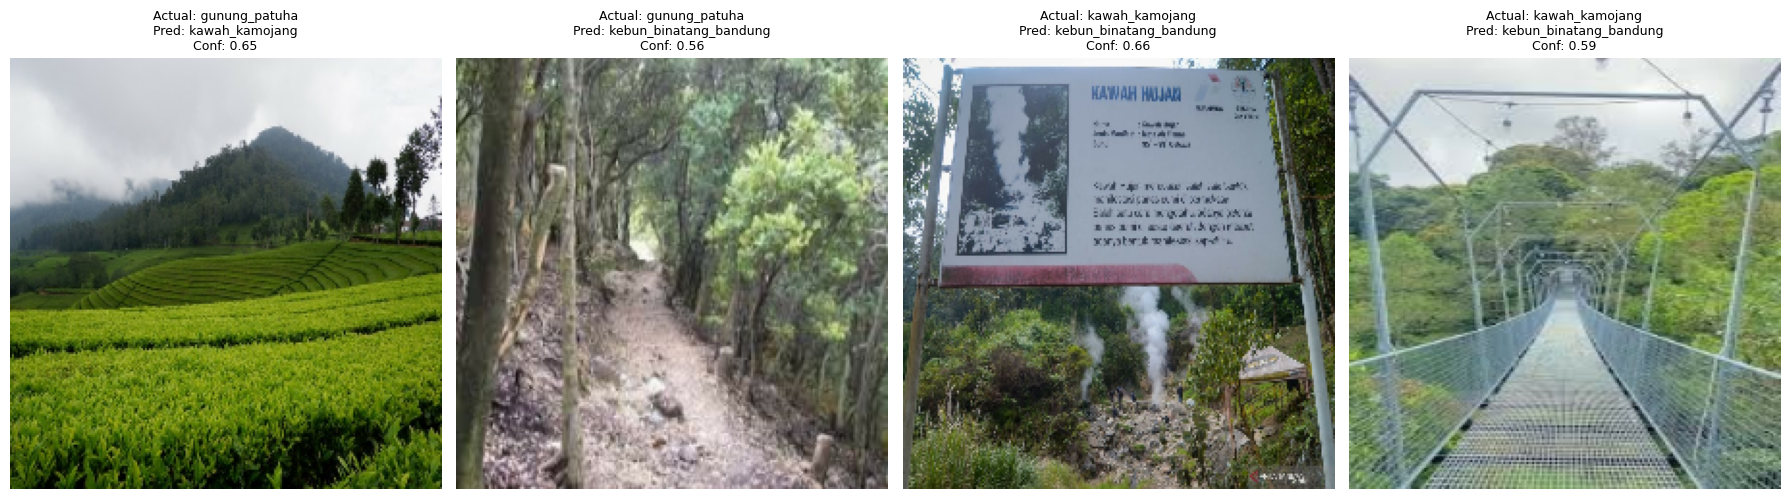

In [57]:
plt.figure(figsize=(18, 14))
for i, item in enumerate(val_wrong_predictions[:12]):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(item["image"].astype("uint8"))
    plt.title(
        f"Actual: {item['actual']}\nPred: {item['predicted']}\nConf: {item['confidence']:.2f}",
        fontsize=9
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [58]:
test_wrong_predictions = []
test_total = 0
for images, labels in test_ds:
    preds = cnn_model.predict(images, verbose=0)
    for i in range(len(images)):
        test_total += 1
        actual_idx = int(np.argmax(labels[i].numpy()))
        pred_idx = int(np.argmax(preds[i]))
        confidence = float(np.max(preds[i]))
        if actual_idx != pred_idx:
            test_wrong_predictions.append({
                "actual": class_names[actual_idx],
                "predicted": class_names[pred_idx],
                "confidence": confidence,
                "image": images[i].numpy()
            })
test_wrong = len(test_wrong_predictions)
test_correct = test_total - test_wrong
test_acc_manual = test_correct / test_total

print("Total test :", test_total)
print("Benar test :", test_correct)
print("Salah test :", test_wrong)
print("Test acc   :", round(test_acc_manual, 4))

Total test : 16
Benar test : 15
Salah test : 1
Test acc   : 0.9375


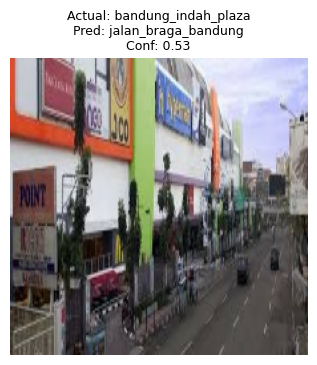

In [59]:
plt.figure(figsize=(14, 10))
for i, item in enumerate(test_wrong_predictions[:9]):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(item["image"].astype("uint8"))
    plt.title(
        f"Actual: {item['actual']}\nPred: {item['predicted']}\nConf: {item['confidence']:.2f}",
        fontsize=9
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [60]:
cnn_model = tf.keras.models.load_model("models/furap_cnn_model.keras")
test_loss, test_accuracy = cnn_model.evaluate(test_ds)
print("Test Loss    :", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning:

Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 



1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9375 - loss: 0.5416
Test Loss    : 0.5416
Test Accuracy: 0.9375


In [62]:
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = cnn_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)
fig = px.imshow(
    cm_df,
    text_auto=True,
    title="Confusion Matrix - MobileNetV2 Test Set",
    color_continuous_scale="Blues"
)
fig.update_layout(width=950, height=850)
fig.show()

                        precision    recall  f1-score   support

     alun_alun_bandung       1.00      1.00      1.00         2
   bandung_indah_plaza       1.00      0.50      0.67         2
         gunung_patuha       1.00      1.00      1.00         2
   jalan_braga_bandung       0.67      1.00      0.80         2
        kawah_kamojang       1.00      1.00      1.00         2
kebun_binatang_bandung       1.00      1.00      1.00         2
museum_geologi_bandung       1.00      1.00      1.00         2
  trans_studio_bandung       1.00      1.00      1.00         2

              accuracy                           0.94        16
             macro avg       0.96      0.94      0.93        16
          weighted avg       0.96      0.94      0.93        16



## Evaluasi visual actual vs predicted

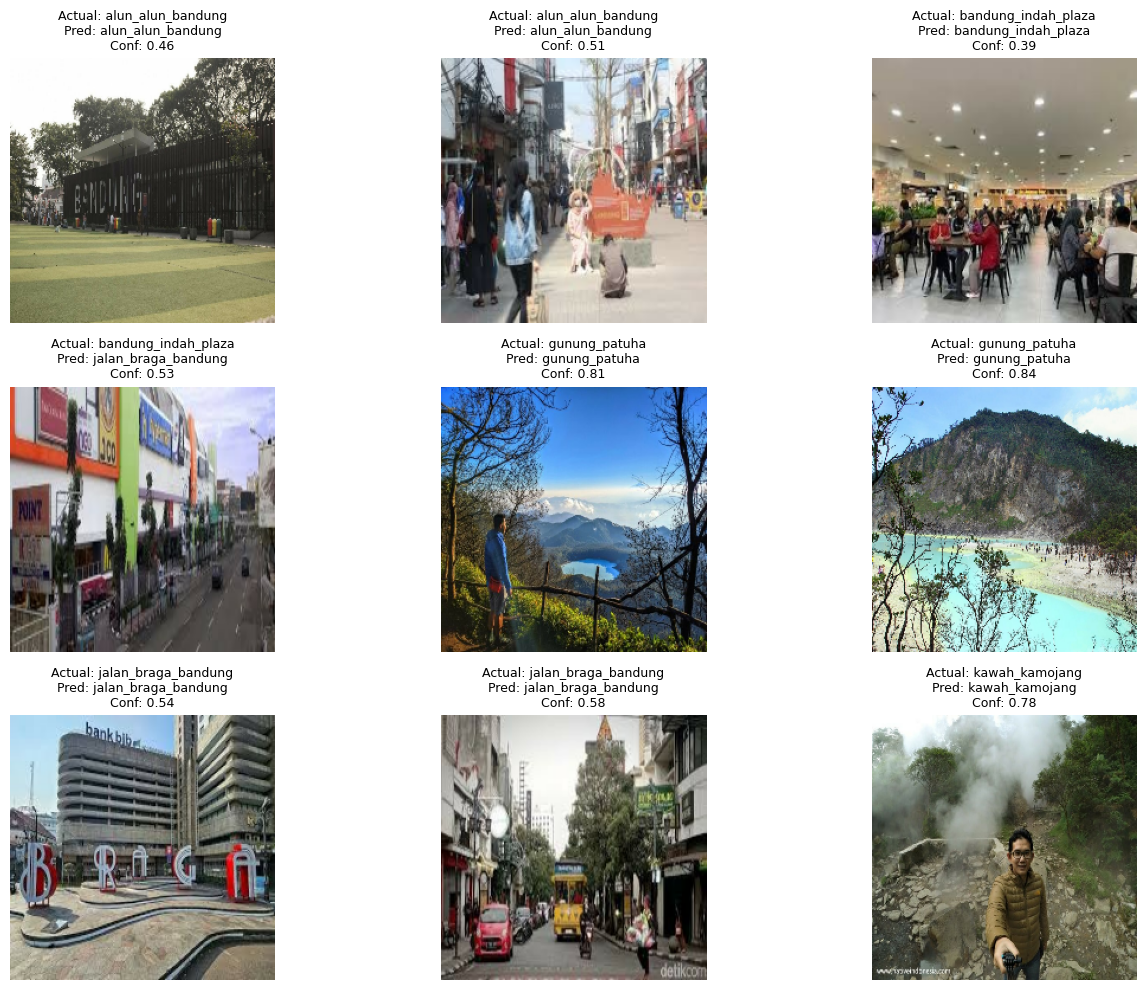

In [64]:
plt.figure(figsize=(14, 10))
for images, labels in test_ds.take(1):
    preds = cnn_model.predict(images, verbose=0)
    for i in range(min(9, len(images))):
        actual_idx = int(np.argmax(labels[i].numpy()))
        pred_idx = int(np.argmax(preds[i]))
        confidence = float(np.max(preds[i]))
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Actual: {class_names[actual_idx]}\nPred: {class_names[pred_idx]}\nConf: {confidence:.2f}",
            fontsize=9
        )
        plt.axis("off")
plt.tight_layout()
plt.show()

## Save CNN Artifact

In [66]:
Path("models").mkdir(exist_ok=True)
cnn_model.save("models/furap_cnn_model.keras")
with open("models/furap_cnn_classes.txt", "w", encoding="utf-8") as file:
    for class_name in class_names:
        file.write(class_name + "\n")
print("Model CNN dan class names berhasil disimpan ke folder models/.")

Model CNN dan class names berhasil disimpan ke folder models/.
